This notebook runs **normative modeling** of **dynamic functional connectivity** data **per network** as a function of **age**. This enables the build of **normative charts of functional connectivity in healthy aging**, embracing both diversity and uncertainty from a cohort of 1000 healthy subjects. A battery of models (statistical frameorks) are fitted to the empirical data through Hierarchical Bayesian Regression proposed in the package Predictive Clinical Neuroscience toolkit (pcntoolkit, https://pcntoolkit.readthedocs.io/en/latest/). The trade-off between predictive power and complexity of the models is assessed through bayesian model comparison, guiding for the choice of an adequate normative model describing this empirical data of functional connectivity. 

In [1]:
import warnings
#removing annoying warnings related to pymc dependencies in pcntoolkit 
warnings.filterwarnings("ignore", category=FutureWarning)

import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize':14, 'axes.titlesize':16})
import pickle
import pcntoolkit as ptk  
import arviz as az
from itertools import product


from funcs import *

## Loading the data

Here a .json containing demographic data of subjects and their FC matrices computed from BOLD FMRI recordings.

In [2]:
cwd = os.getcwd()

In [3]:
fcd_df = pd.read_pickle('../7NetFCDs.pkl')

In [4]:
fcd_df.head()

,id,Age,Net,fcd,FCD,Mean_triuFCD,Var_triuFCD
0,850,33.1,Vis,"[[0.9999999, 0.99543786, 0.98360366, 0.9660938...","[[0.9999999, 0.99543786, 0.98360366, 0.9660938...",0.469254,0.073895
1,850,33.1,SomMot,"[[1.0, 0.98009795, 0.92479765, 0.8464932, 0.76...","[[1.0, 0.98009795, 0.92479765, 0.8464932, 0.76...",0.533376,0.102247
2,850,33.1,DorsAttn,"[[1.0, 0.9816981, 0.9469556, 0.9068506, 0.8576...","[[1.0, 0.9816981, 0.9469556, 0.9068506, 0.8576...",0.444840,0.046862
3,850,33.1,SalVentAttn,"[[0.99999994, 0.9801285, 0.9550817, 0.9421648,...","[[0.99999994, 0.9801285, 0.9550817, 0.9421648,...",0.400429,0.047214
4,850,33.1,Limbic,"[[1.0, 0.99812245, 0.9910641, 0.9781956, 0.959...","[[1.0, 0.99812245, 0.9910641, 0.9781956, 0.959...",0.454816,0.098075


In [5]:
fcd_df.isna().sum()

id              0
Age             0
Net             0
fcd             0
FCD             0
Mean_triuFCD    0
Var_triuFCD     0
dtype: int64

In [7]:
nets = fcd_df['Net'].unique()

In [8]:
new_df = fcd_df[["id", "Net", "Var_triuFCD"]].pivot(index=['id'], columns='Net')
new_df.columns = new_df.columns.map('_'.join)
df = fcd_df[['id', 'Age']].join(new_df, on='id')
df.head()

,id,Age,Var_triuFCD_Cont,Var_triuFCD_Default,Var_triuFCD_DorsAttn,Var_triuFCD_Limbic,Var_triuFCD_SalVentAttn,Var_triuFCD_SomMot,Var_triuFCD_Vis
0,850,33.1,0.073212,0.034966,0.046862,0.098075,0.047214,0.102247,0.073895
1,850,33.1,0.073212,0.034966,0.046862,0.098075,0.047214,0.102247,0.073895
2,850,33.1,0.073212,0.034966,0.046862,0.098075,0.047214,0.102247,0.073895
3,850,33.1,0.073212,0.034966,0.046862,0.098075,0.047214,0.102247,0.073895
4,850,33.1,0.073212,0.034966,0.046862,0.098075,0.047214,0.102247,0.073895


In [12]:
df = df.drop_duplicates()
df.head()

,id,Age,Var_triuFCD_Cont,Var_triuFCD_Default,Var_triuFCD_DorsAttn,Var_triuFCD_Limbic,Var_triuFCD_SalVentAttn,Var_triuFCD_SomMot,Var_triuFCD_Vis
0,850,33.1,0.073212,0.034966,0.046862,0.098075,0.047214,0.102247,0.073895
7,620,72.2,0.029123,0.023444,0.022016,0.105156,0.031819,0.023270,0.034548
14,1279,59.4,0.003574,0.008837,0.034784,0.101720,0.021261,0.041622,0.013082
21,591,71.7,0.028041,0.019961,0.026422,0.125554,0.048538,0.027625,0.063181
28,271,51.6,0.031402,0.027364,0.025650,0.103777,0.030538,0.032758,0.048275


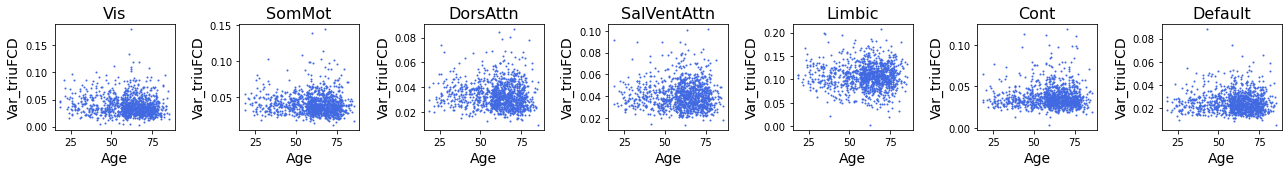

In [13]:
x = 'Age'; y = 'Var_triuFCD'
fig, ax = plt.subplots(ncols=7, figsize=(18, 2.5))
for i, net in enumerate(nets) :
    y_net = y + '_' + net
    ax[i].scatter(df[x], df[y_net], s=1, color='royalblue')
    ax[i].set(title=net, xlabel='Age', ylabel=y)
fig.tight_layout()

In [14]:
del fcd_df
del new_df

We fit different parameterizations of linear models to each of the network-FC as a function of age and we select the best fit based on model comparison.

In [10]:
#Run and save all models 
x_str = 'Age'; y = 'Var_triuFCD_'
for net in nets :
    y_str = y + net
    models_dict = run_all(df, x_str, y_str, reg_type='linear')

Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Var_triuFCD_Vis.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.
There were 437 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


...

Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Var_triuFCD_Default.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 113 seconds.


In [15]:
#Load models and perform model comparison, per each network
x_str = 'Age'; y = 'Var_triuFCD_'
model_names = get_names(reg_type='linear')
best_list = []
for net in nets :
    y_str = y + net
    _, compared = compare_from_pickles(df, x_str, y_str, model_names)
    del _
    best = get_best(compared)
    best_list.append(best)

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

/media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/funcs.py:329: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:976: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x)
/home/tng/.local/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior a

In [16]:
#Load best model per network
nms = []
for b, net in zip(best_list, nets) :
    print(net, 'best :', b)
    y_str = y + net
    nm = nm_from_pickle(x_str, y_str, b)
    nms.append(nm)

Vis best : lin_shash_all
SomMot best : lin_shash_sig_del
DorsAttn best : lin_shash_sig
SalVentAttn best : lin_shash_sig
Limbic best : lin_het
Cont best : lin_shash_sig_del
Default best : lin_shash_sig_del


We plot the best fit for each network

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

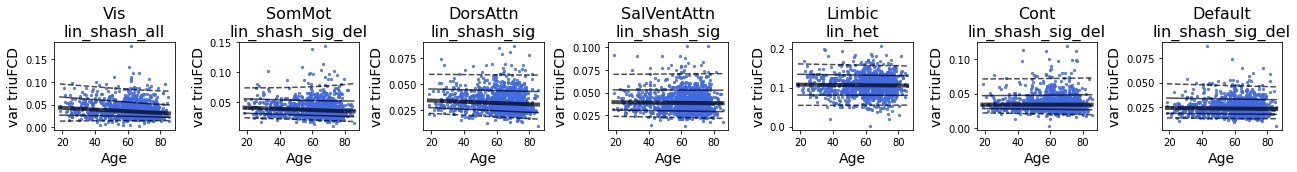

In [20]:
fig, ax = plt.subplots(ncols=7, figsize=(18, 2.5))
for i, net in enumerate(nets) :
    y_str = y + net
    inscaler = ptk.util.utils.scaler('standardize') 
    outscaler = ptk.util.utils.scaler('standardize')
    outscaler.fit(df[y_str])
    a=plot_quantiles(nms[i], df, x_str, y_str, inscaler, outscaler, n_qs=2, ax=ax[i])
    ax[i].set(title=net + '\n' + best_list[i], xlabel='Age', ylabel='var triuFCD')
    #ax[i].axhline(df[y_str].mean(), linestyle='--', lw=2, color='red', alpha=.8)
fig.tight_layout()